[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch07.ipynb)

Notebook Bab 7 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Seleksi fitur membuang fitur redundan dan *noise*. Kita bandingkan metode *filter*, *wrapper*, dan *embedded*, semuanya di dalam *pipeline* agar tidak bocor.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Seleksi Fitur pada WDBC


## Data: fitur nyata + probe noise

WDBC berisi 30 fitur numerik nyata dari citra FNA tumor. Untuk membuat kontrol *noise* terlihat, notebook menambahkan 20 kolom `probe_noise_*` secara sintetis. Identitas dataset tetap WDBC; probe hanya alat pembanding untuk metode seleksi.


In [2]:
DATA_DIR = section_data_dir('ch07_wdbc')
wdbc = pd.read_parquet(DATA_DIR / 'wdbc.parquet')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

X_real = wdbc.drop(columns=['diagnosis', 'malignant'])
y = wdbc['malignant']
X = X_real.copy()
for i in range(stats['probe_noise_count_for_notebook_demo']):
    X[f'probe_noise_{i+1:02d}'] = rng.normal(size=len(X))

print(f"Rows: {stats['rows']:,} | Real numeric features: {stats['real_feature_count']} | Probe noise: {stats['probe_noise_count_for_notebook_demo']}")
print(f"Target counts: {stats['target_counts']}")
print(f"Missing cells: {stats['missing_cells']}")
print(f"Pairs abs(corr)>0.90: {stats['abs_corr_pairs_gt_0_90']} | abs(corr)>0.95: {stats['abs_corr_pairs_gt_0_95']}")
print()
print('Top correlated real-feature pairs:')
print(pd.read_csv(DATA_DIR / 'top_correlated_feature_pairs.csv').head(6).to_string(index=False, float_format=lambda x: f'{x:.4f}'))


Rows: 569 | Real numeric features: 30 | Probe noise: 20
Target counts: {'benign': 357, 'malignant': 212}
Missing cells: 0
Pairs abs(corr)>0.90: 21 | abs(corr)>0.95: 15

Top correlated real-feature pairs:
      feature_a       feature_b  abs_corr
    mean radius  mean perimeter    0.9979
   worst radius worst perimeter    0.9937
    mean radius       mean area    0.9874
 mean perimeter       mean area    0.9865
   worst radius      worst area    0.9840
worst perimeter      worst area    0.9776


## Filter vs wrapper vs embedded

Semua selektor berada di dalam `Pipeline`, sehingga pemilihan fitur di-*fit* hanya pada fold pelatihan. Nilai `k` dan kekuatan L1 dibuat tetap agar demo ringan; jika keduanya ikut dituning, gunakan validasi bersarang seperti pada Bab 2.


              metode  ROC_AUC_mean  ROC_AUC_std
all_30_real_20_probe        0.9940       0.0076
          filter_k10        0.9915       0.0062
             rfe_k10        0.9962       0.0027
         l1_embedded        0.9958       0.0042

Fitur terpilih saat fit pada seluruh data untuk display:
     metode  jumlah_fitur  probe_terpilih                                                                     contoh_fitur
 filter_k10            10               0      mean radius, mean perimeter, mean area, mean concavity, mean concave points
    rfe_k10            10               0    mean compactness, mean concave points, radius error, area error, worst radius
l1_embedded             8               0 mean concave points, radius error, worst radius, worst texture, worst smoothness


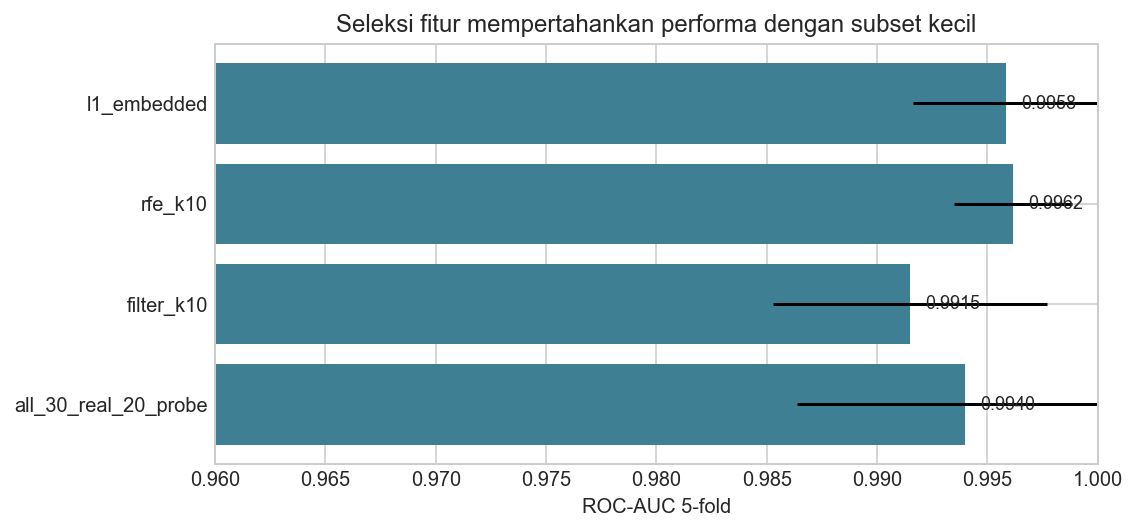

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def l2_lr():
    return LogisticRegression(max_iter=4000, solver='liblinear')

def l1_lr(C=0.08):
    return LogisticRegression(max_iter=4000, solver='liblinear', C=C, l1_ratio=1)

pipelines = {
    'all_30_real_20_probe': Pipeline([
        ('scaler', StandardScaler()),
        ('model', l2_lr()),
    ]),
    'filter_k10': Pipeline([
        ('select', SelectKBest(mutual_info_classif, k=10)),
        ('scaler', StandardScaler()),
        ('model', l2_lr()),
    ]),
    'rfe_k10': Pipeline([
        ('scaler', StandardScaler()),
        ('select', RFE(l2_lr(), n_features_to_select=10, step=10)),
        ('model', l2_lr()),
    ]),
    'l1_embedded': Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectFromModel(l1_lr(C=0.08), threshold=1e-5)),
        ('model', l2_lr()),
    ]),
}

rows = []
selected_rows = []
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    rows.append({'metode': name, 'ROC_AUC_mean': scores.mean(), 'ROC_AUC_std': scores.std()})
    if 'select' in pipe.named_steps:
        pipe.fit(X, y)
        support = pipe.named_steps['select'].get_support()
        names = list(X.columns[support])
        selected_rows.append({
            'metode': name,
            'jumlah_fitur': len(names),
            'probe_terpilih': sum(n.startswith('probe_noise_') for n in names),
            'contoh_fitur': ', '.join(names[:5]),
        })

score_df = pd.DataFrame(rows)
selected_df = pd.DataFrame(selected_rows)
print(score_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
print('Fitur terpilih saat fit pada seluruh data untuk display:')
print(selected_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(score_df['metode'], score_df['ROC_AUC_mean'], xerr=score_df['ROC_AUC_std'], color='#3f7f93')
ax.set_xlim(0.96, 1.0)
ax.set_xlabel('ROC-AUC 5-fold')
ax.set_title('Seleksi fitur mempertahankan performa dengan subset kecil')
for i, value in enumerate(score_df['ROC_AUC_mean']):
    ax.text(value + 0.0007, i, f'{value:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## Gambar 7.3: lintasan koefisien L1

Ketika regularisasi L1 makin kuat, sebagian koefisien terdorong menjadi nol. Garis putus-putus adalah probe noise; garis penuh adalah fitur WDBC nyata.


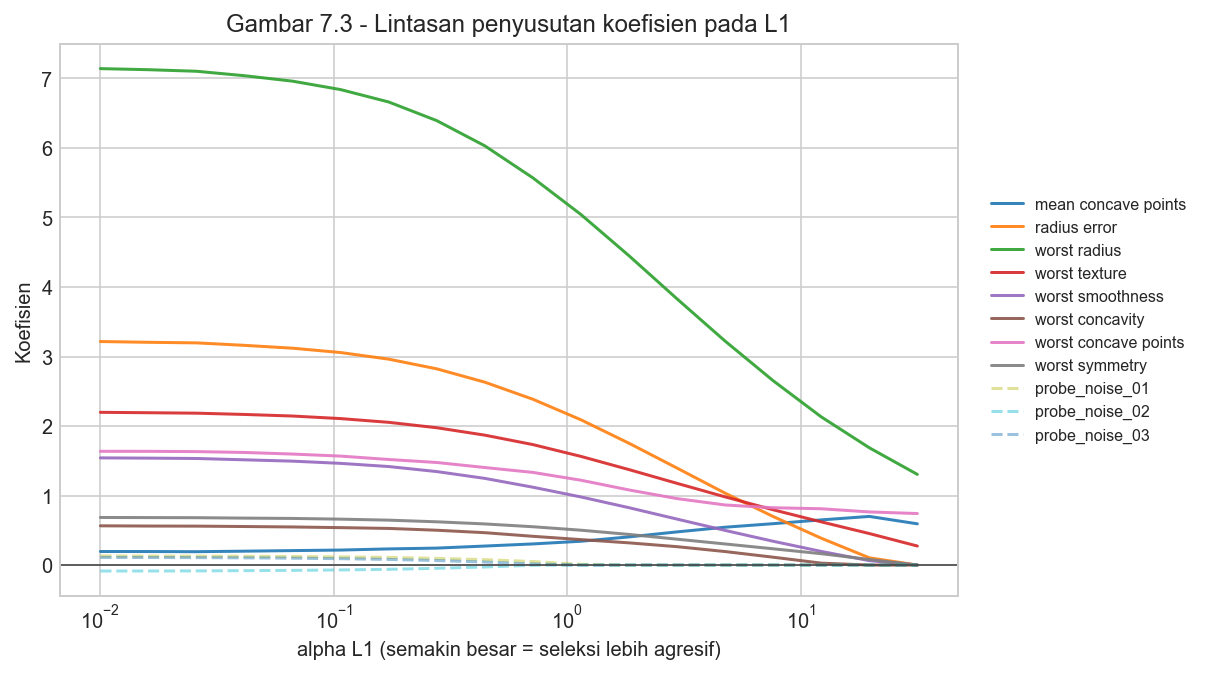

In [4]:
feature_path = [
    'mean concave points', 'radius error', 'worst radius', 'worst texture',
    'worst smoothness', 'worst concavity', 'worst concave points', 'worst symmetry',
    'probe_noise_01', 'probe_noise_02', 'probe_noise_03'
]
X_path = X[feature_path]
X_scaled = StandardScaler().fit_transform(X_path)
alphas = np.logspace(-2, 1.5, 18)
coefs = []
for alpha in alphas:
    model = l1_lr(C=1 / alpha)
    model.fit(X_scaled, y)
    coefs.append(model.coef_[0])
coefs = np.vstack(coefs)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for j, name in enumerate(feature_path):
    linestyle = '--' if name.startswith('probe') else '-'
    alpha = 0.45 if name.startswith('probe') else 0.9
    ax.plot(alphas, coefs[:, j], linestyle=linestyle, alpha=alpha, label=name)
ax.axhline(0, color='#444444', linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('alpha L1 (semakin besar = seleksi lebih agresif)')
ax.set_ylabel('Koefisien')
ax.set_title('Gambar 7.3 - Lintasan penyusutan koefisien pada L1')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


In [5]:
# Stabilitas sederhana: Jaccard antar fold untuk SelectKBest k=10.
sets = []
for train_idx, _ in cv.split(X, y):
    selector = SelectKBest(mutual_info_classif, k=10)
    selector.fit(X.iloc[train_idx], y.iloc[train_idx])
    sets.append(set(X.columns[selector.get_support()]))

jaccards = []
for i in range(len(sets)):
    for j in range(i + 1, len(sets)):
        jaccards.append(len(sets[i] & sets[j]) / len(sets[i] | sets[j]))
print(f'Rata-rata Jaccard SelectKBest antar fold: {np.mean(jaccards):.3f}')
print('Contoh fitur fold pertama:', ', '.join(sorted(sets[0])[:10]))


Rata-rata Jaccard SelectKBest antar fold: 1.000
Contoh fitur fold pertama: area error, mean area, mean concave points, mean concavity, mean perimeter, mean radius, worst area, worst concave points, worst perimeter, worst radius


>
> 🔎 **Amati.** WDBC punya banyak fitur yang sangat berkorelasi, jadi beberapa metode dapat memilih subset berbeda tetapi tetap mempertahankan performa. Probe noise membantu mengecek apakah selector hanya menangkap kebetulan; pada fit display ini, tidak ada probe yang terpilih. Jaccard antar fold tidak harus 1.0 karena fitur yang saling berkorelasi dapat saling menggantikan, sehingga stabilitas perlu dibaca pada tingkat kelompok sinyal juga.


## Section 2 - Mini Project

## Soal

Anda diberi data berdimensi tinggi (80 fitur, banyak *noise*). Targetnya klasifikasi biner.

Tugas:

1. Bandingkan dua metode seleksi (misalnya *filter* dan *embedded*) di dalam *pipeline*.
2. Periksa **stabilitas** seleksi: fitur mana yang konsisten terpilih antar-*fold*?
3. Laporkan akurasi dan jumlah fitur terpilih tiap metode.

**Luaran:** kode perbandingan, daftar fitur stabil, dan 2-3 kalimat kesimpulan.

**Kriteria penilaian:** (a) selektor di dalam *pipeline*; (b) ada analisis stabilitas antar-*fold*; (c) perbandingan adil (model akhir sama).

In [6]:
# DATA AWAL (jangan diubah) - 80 fitur, 10 informatif, 8 redundan.
Xm, ym = make_classification(n_samples=1500, n_features=80, n_informative=10,
                             n_redundant=8, random_state=7)
print('Data:', Xm.shape)


Data: (1500, 80)


In [7]:
# Kerjakan di sini.
# Petunjuk: SelectKBest / SelectFromModel di dalam Pipeline; cek get_support() tiap fold.
